In [9]:
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv("../data/processed/fut_prices_features.csv", parse_dates= ["date"])

In [3]:
#train, test and validation split to avoid overfitting (70/15/15).
train_split = df["date"].quantile(0.7)
validation_split = df["date"].quantile(0.85)

train = df[df["date"] <= train_split]
val = df[(df["date"] > train_split) & (df["date"] <= validation_split)]
test = df[df["date"] > validation_split]

X_train = train.drop(["price", "date", "player_name"], axis=1)
y_train = train["price"]

X_val = val.drop(["price", "date", "player_name"], axis=1)
y_val = val["price"]

X_test = test.drop(["price", "date", "player_name"], axis=1)
y_test = test["price"]

In [4]:
#create the objective function that will evaluate the prediction on the validation data
def objective(trial): 
    parameters = {"n_estimators": trial.suggest_int("n_estimators", 500, 1500), 
                  "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), 
                  "max_depth": trial.suggest_int("max_depth", 3, 8), 
                  "subsample": trial.suggest_float("subsample", 0.6, 0.9), 
                  "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9), 
                  "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0), 
                  "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.0), 
                  "n_jobs": 1, 
                  "tree_method": "hist", 
                  "random_state": 42} 
    
    model = XGBRegressor(**parameters) 
    model.fit(X_train, y_train) 
    validation_prediction = model.predict(X_val) 
    mae = mean_absolute_error(y_val, validation_prediction) 
    return mae

In [5]:
#start the optimization search with optuna and retrieve the best parameters
search = optuna.create_study(direction="minimize")
search.optimize(objective, n_trials=25)

best_parameters = search.best_params
best_parameters["n_jobs"] = 1
best_parameters["tree_method"] = "hist"
best_parameters["random_state"] = 42

best_parameters

[I 2026-02-24 01:12:32,099] A new study created in memory with name: no-name-76c1c8ab-65cd-4d89-bb56-5f64b14da786
[I 2026-02-24 01:12:32,939] Trial 0 finished with value: 1024.0464597759824 and parameters: {'n_estimators': 1030, 'learning_rate': 0.0764300780319207, 'max_depth': 3, 'subsample': 0.6087363215772716, 'colsample_bytree': 0.7742200643941836, 'reg_alpha': 0.3680950704416369, 'reg_lambda': 1.4183270414325873}. Best is trial 0 with value: 1024.0464597759824.
[I 2026-02-24 01:12:33,545] Trial 1 finished with value: 1510.6343611900252 and parameters: {'n_estimators': 757, 'learning_rate': 0.011957894030014932, 'max_depth': 3, 'subsample': 0.6883250736851281, 'colsample_bytree': 0.775114044925811, 'reg_alpha': 0.04841058196417358, 'reg_lambda': 0.7076206014088948}. Best is trial 0 with value: 1024.0464597759824.
[I 2026-02-24 01:12:36,500] Trial 2 finished with value: 494.7018294928451 and parameters: {'n_estimators': 1039, 'learning_rate': 0.011595926727531751, 'max_depth': 7, 's

{'n_estimators': 1384,
 'learning_rate': 0.05713235007299071,
 'max_depth': 7,
 'subsample': 0.6436924920178506,
 'colsample_bytree': 0.868423335460131,
 'reg_alpha': 0.7004741542130335,
 'reg_lambda': 0.7516479577753957,
 'n_jobs': 1,
 'tree_method': 'hist',
 'random_state': 42}

In [6]:
#retrain the model with the tuned parameters on training AND validation data
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

tuned_xgb = XGBRegressor(**best_parameters)
tuned_xgb.fit(X_train_full, y_train_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.868423335460131
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [7]:
#make predictions on test data with the tuned XGBoost model
tuned_prediction = tuned_xgb.predict(X_test)

mae_optuna = mean_absolute_error(y_test, tuned_prediction)
mape_optuna = mean_absolute_percentage_error(y_test, tuned_prediction)

print(f"On average, the model's predictions are off by {mae_optuna:.2f} coins, with percentage errors averaging {mape_optuna*100:.2f}% across all players in the dataset.")


On average, the model's predictions are off by 267.96 coins, with percentage errors averaging 3.63% across all players in the dataset.


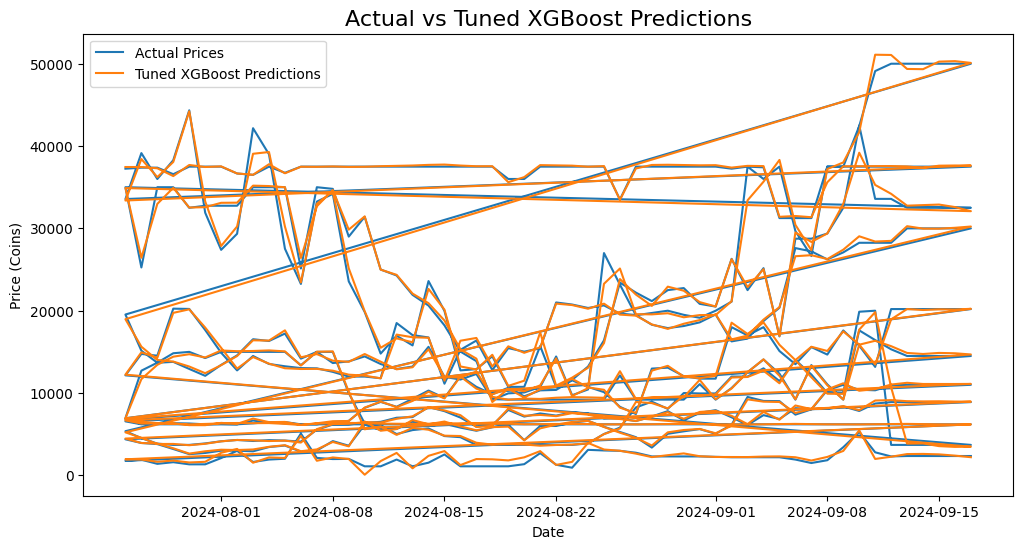

In [10]:
plt.figure(figsize=(12,6))
plt.plot(test["date"], y_test, label="Actual Prices")
plt.plot(test["date"], tuned_prediction, label="Tuned XGBoost Predictions")
plt.title("Actual vs Tuned XGBoost Predictions", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (Coins)")
plt.legend()
plt.show()
